# 🏥 Medical Insurance Cost Predictor — Progressive ML & MLOps Notebook

**Progressive Modeling Strategy (Occam's Razor):**
1. **Stage 1:** Simple Baseline Models (Linear, Ridge, Lasso, Decision Tree)
2. **Stage 2:** Complex Models (Random Forest, XGBoost, LightGBM, GBDT)
3. **Stage 3:** Hyperparameter Tuning on Best Performing Model(s) via Optuna (100 Bayesian Trials across expanded search space)
4. **Stage 4:** Advanced Stacking Meta-Ensemble & Quantile Regression

**Applied Optimization Strategies:**
- **Polynomial Feature Engineering:** $BMI^2$, $Age^2$, and $Age \times Smoker$ interaction.
- **4-Level Ordinal BMI Risk Tiering:** $0=\text{Normal/Underweight (<25)}$, $1=\text{Overweight (25-30)}$, $2=\text{Obese (30-35)}$, $3=\text{Morbidly Obese (}\ge 35\text{)}$.
- **100-Trial Optuna Search:** Expanded search space including `gamma`, `reg_alpha`, `reg_lambda`, `min_child_weight`, `colsample_bylevel`.

---

## 1. Data Ingestion & Schema Validation
Programmatic download and domain schema validation checks (0 nulls, age [18-100], BMI [10-60], charges >= 0).

In [40]:
%load_ext autoreload
%autoreload 2
import sys
import importlib
sys.path.append("..")
import pandas as pd
import numpy as np

import src.data_validation
importlib.reload(src.data_validation)
from src.data_ingestion import load_raw_data
try:
    from src.data_validation import validate_raw_data
except ImportError:
    from src.data_validation import validate_data as validate_raw_data

df = load_raw_data("../params.yaml")
res = validate_raw_data(df)
is_valid = res[0] if isinstance(res, tuple) else res

print(f"Validation Status: {'✅ PASSED' if is_valid else '❌ FAILED'}")
df.head()

2026-07-31 23:16:11,712 - INFO - Dataset already exists at data/raw/insurance.csv
2026-07-31 23:16:11,715 - INFO - Loaded dataset: 1338 rows, 7 columns
2026-07-31 23:16:11,717 - INFO - ✅ Data Validation Passed: 0 nulls, correct schema, valid ranges.


Validation Status: ✅ PASSED


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Exploratory Data Analysis (EDA) & Feature Visualizations
Generating EDA plots to uncover multi-collinearity, skewed distributions, and interaction patterns.

2026-07-31 23:16:23,147 - INFO - Generated 3 EDA plots in ../reports/figures


📌 Target Distribution: Raw vs Log-Transformed Charges: ../reports/figures\charges_distribution.png


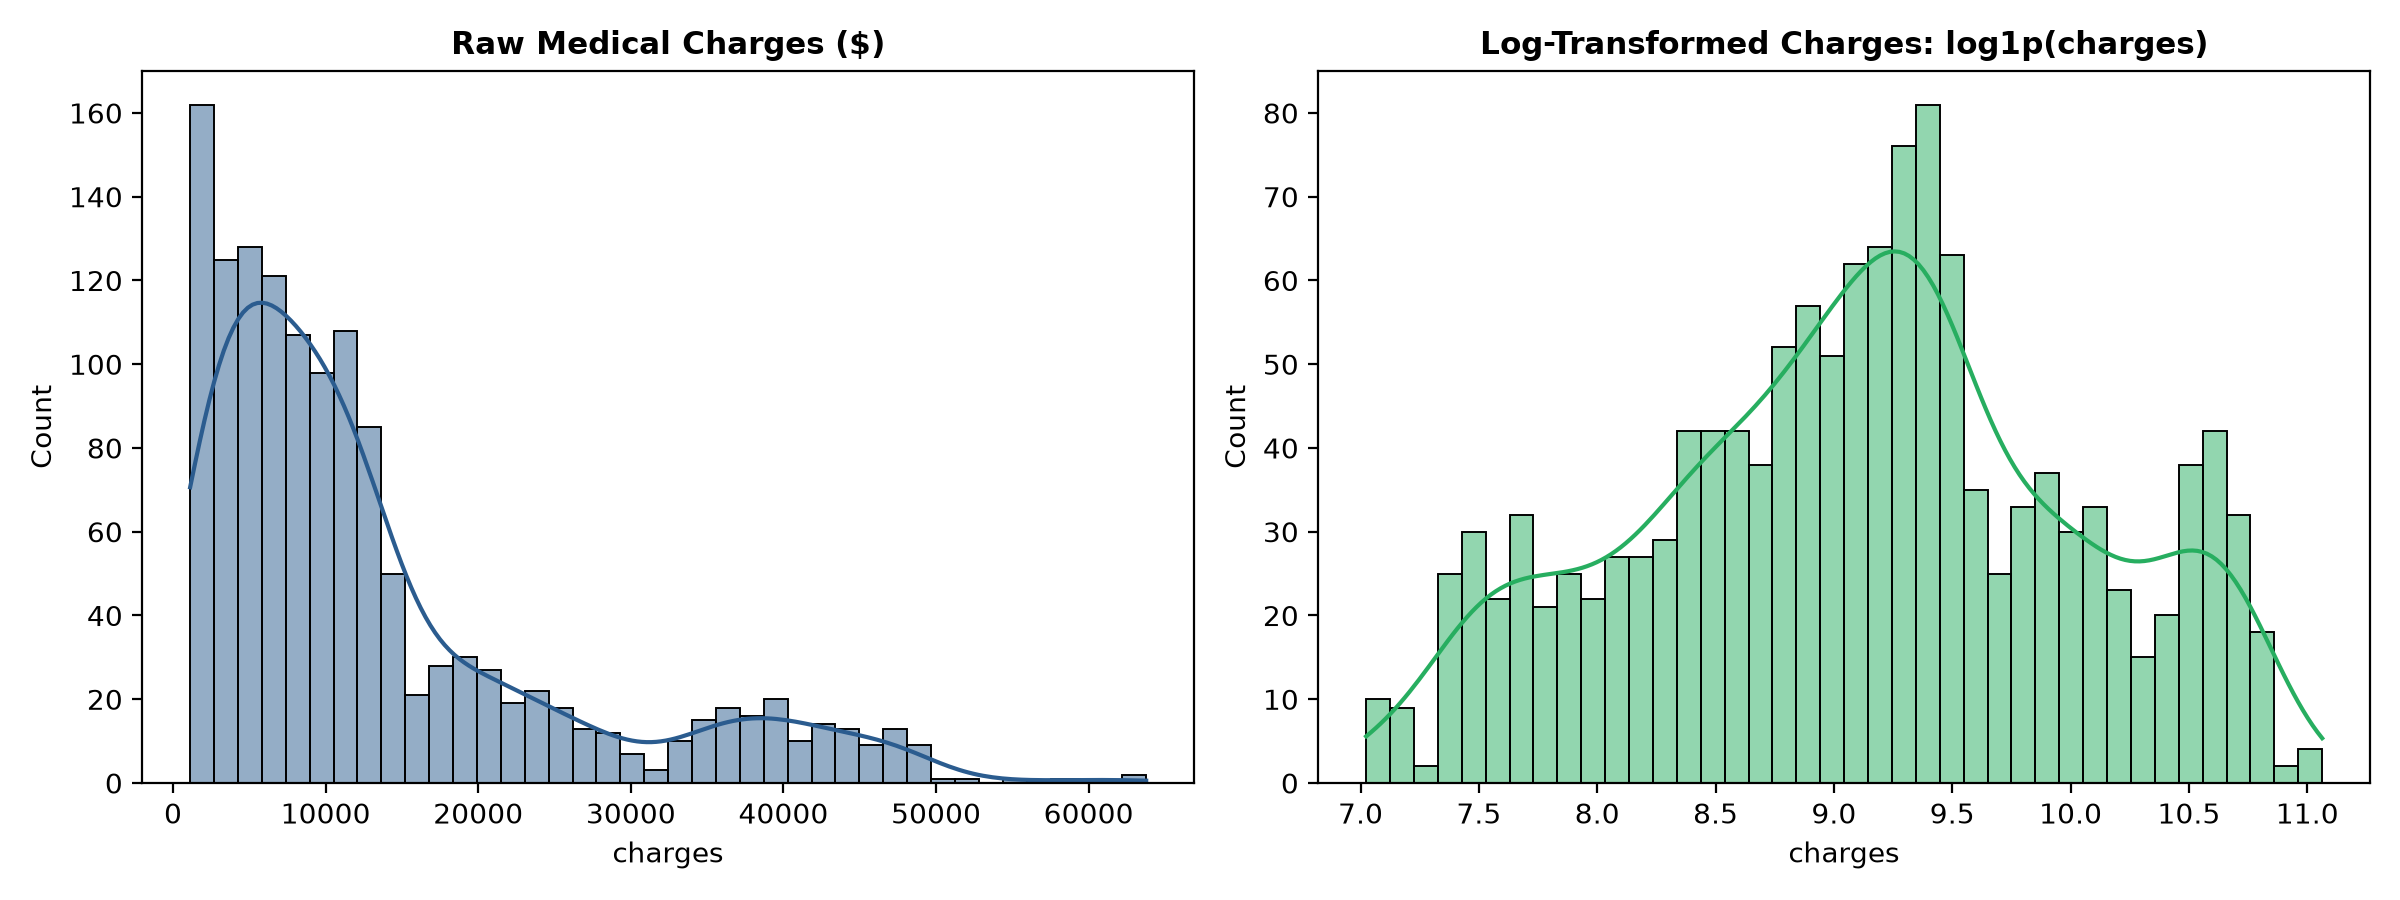

📌 BMI vs Medical Charges Segmented by Smoker Status: ../reports/figures\smoker_bmi_interaction.png


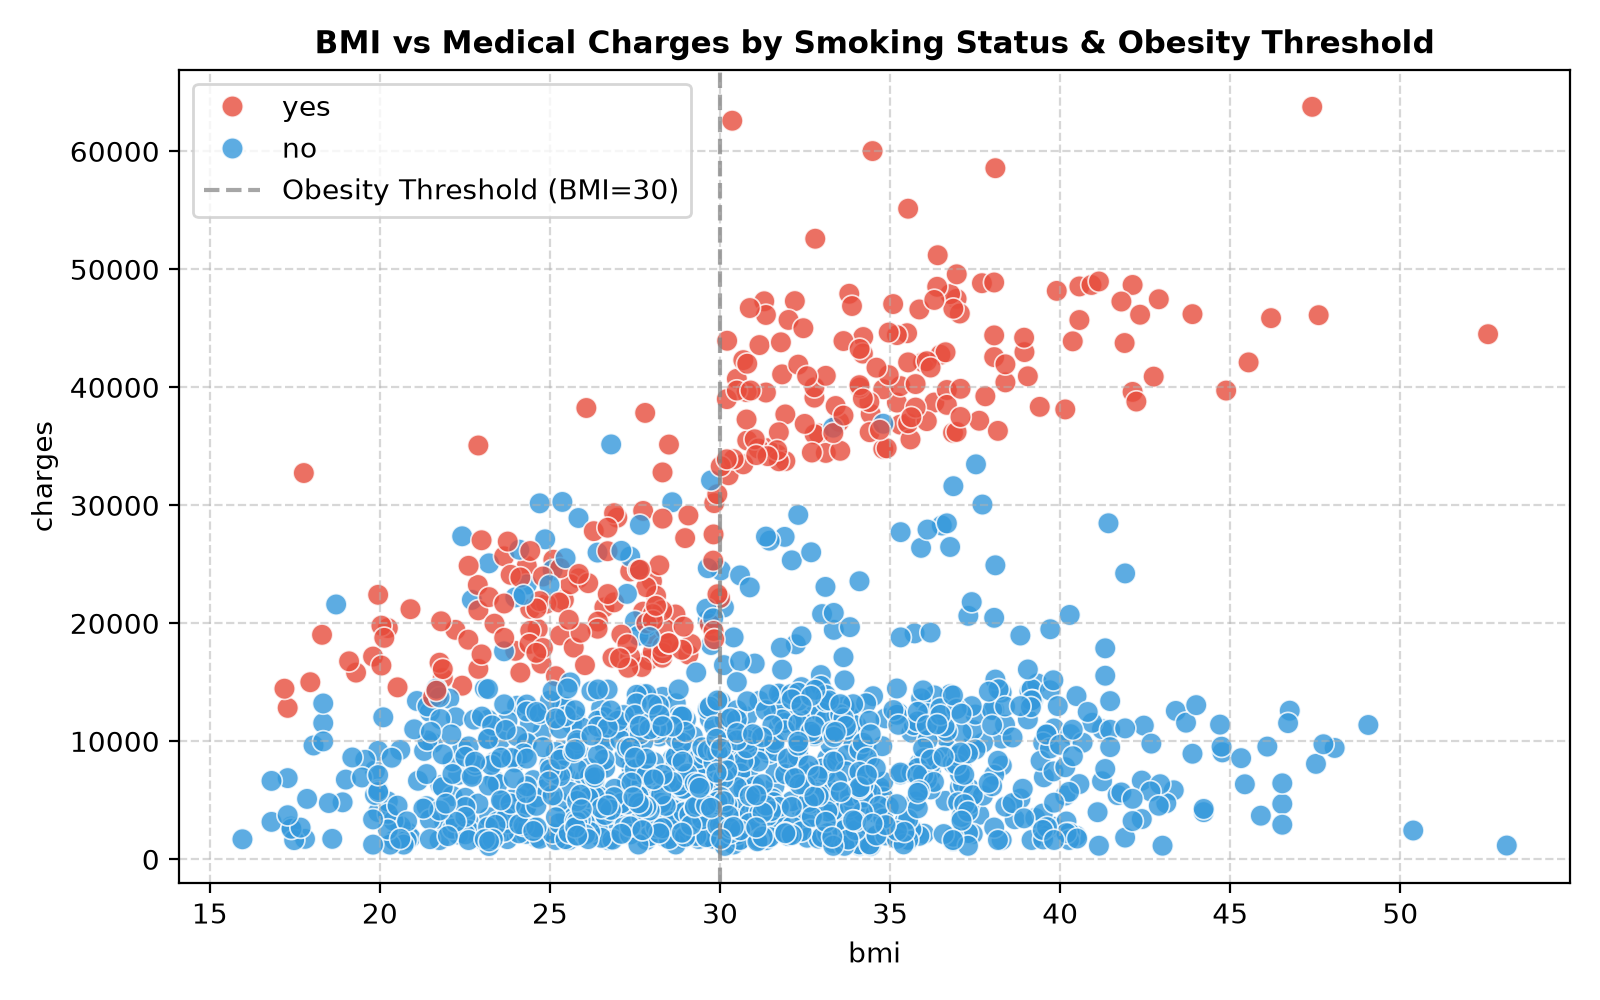

📌 Feature Correlation Heatmap with Target: ../reports/figures\correlation_heatmap.png


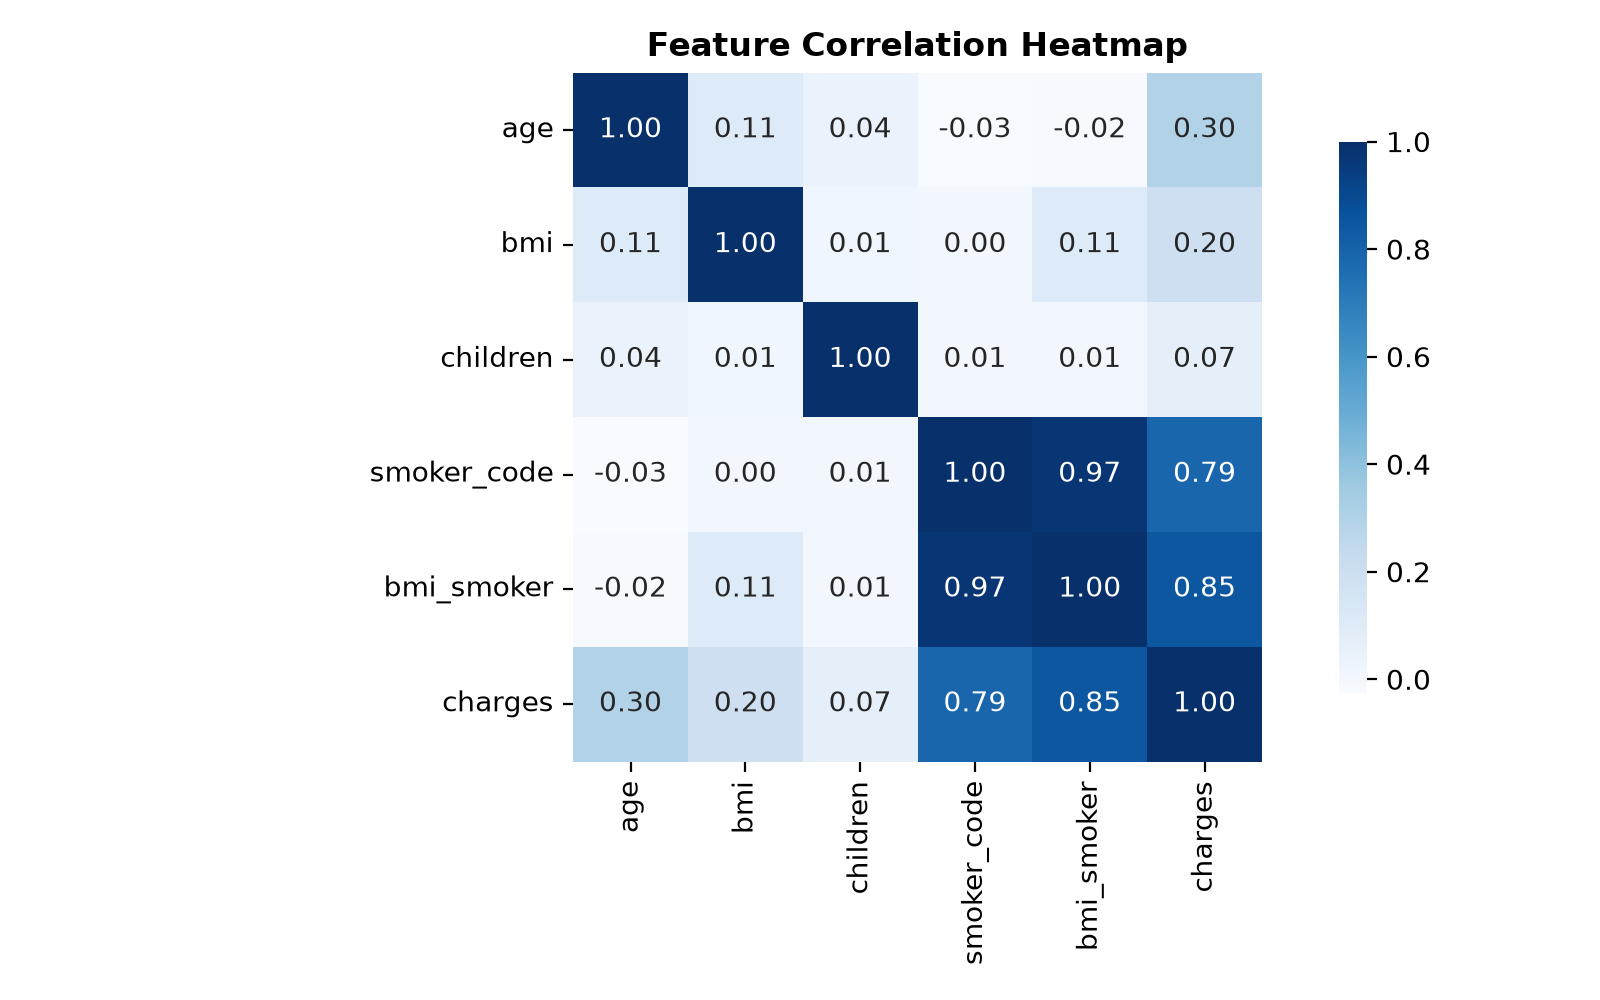

In [41]:
from src.data_preprocessing import generate_eda_plots
from IPython.display import Image, display

eda_figs = generate_eda_plots(df, output_dir="../reports/figures")
for img_path, caption in eda_figs:
    print(f"📌 {caption}: {img_path}")
    display(Image(filename=img_path))

## 3. Feature Preprocessing & Pipeline Construction
Applying:
1. **Polynomial Transformations:** `bmi_sq` ($BMI^2$), `age_sq` ($Age^2$), `age_smoker` ($Age \times Smoker$)
2. **BMI Risk Tiering (Ordinal):** Categorizing BMI into 4 clinical risk levels (0=Normal, 1=Overweight, 2=Obese, 3=Morbidly Obese)
3. **High-Signal Interaction Terms:** `bmi_smoker`, `obese_smoker`, `age_bmi`
4. **Standard Scaling & One-Hot Encoding**

In [42]:
from src.data_preprocessing import create_features, build_preprocessor, prepare_data

df_engineered = create_features(df)
print("Engineered Feature Columns:\n")
df_engineered.head()

Engineered Feature Columns:



,age,sex,bmi,children,smoker,region,charges,bmi_sq,age_sq,age_smoker,bmi_risk_tier,bmi_smoker,obese_smoker,age_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,778.410000,361,19,1,27.9,0,530.100
1,18,male,33.770,1,no,southeast,1725.55230,1140.412900,324,0,2,0.0,0,607.860
2,28,male,33.000,3,no,southeast,4449.46200,1089.000000,784,0,2,0.0,0,924.000
3,33,male,22.705,0,no,northwest,21984.47061,515.517025,1089,0,0,0.0,0,749.265
4,32,male,28.880,0,no,northwest,3866.85520,834.054400,1024,0,1,0.0,0,924.160


In [43]:
X_train_proc, X_test_proc, y_train, y_test, preprocessor, _ = prepare_data("../params.yaml")
print(f"X_train processed shape: {X_train_proc.shape}")
print(f"X_test processed shape:  {X_test_proc.shape}")

2026-07-31 23:16:28,146 - INFO - Dataset already exists at data/raw/insurance.csv
2026-07-31 23:16:28,150 - INFO - Loaded dataset: 1338 rows, 7 columns
2026-07-31 23:16:29,425 - INFO - Generated 3 EDA plots in reports/figures
2026-07-31 23:16:29,443 - INFO - Preprocessor saved. Train shape: (1070, 18) | Test shape: (268, 18)


X_train processed shape: (1070, 18)
X_test processed shape:  (268, 18)


## 4. Progressive Model Training Pipeline
Evaluation metrics tracked in log space ($R^2$) and original dollar space ($MAE$, $RMSE$, $MAPE$).

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results_summary = {}

def evaluate_and_log(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred_log = model.predict(X_te)
    y_true_dollar = np.expm1(y_te)
    y_pred_dollar = np.expm1(y_pred_log)
    
    r2 = r2_score(y_te, y_pred_log)
    mae = mean_absolute_error(y_true_dollar, y_pred_dollar)
    rmse = np.sqrt(mean_squared_error(y_true_dollar, y_pred_dollar))
    mape = np.mean(np.abs((y_true_dollar - y_pred_dollar) / y_true_dollar)) * 100
    
    results_summary[name] = {"R2": r2, "MAE": mae, "RMSE": rmse, "MAPE": mape}
    print(f"[{name:30s}] -> R2: {r2:.4f} | MAE ($): ${mae:,.2f} | MAPE: {mape:.2f}%")
    return model, y_pred_log

### Stage 1: Simple Baseline Models
Evaluating linear and shallow decision models on the enhanced feature set.

In [45]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

lr_model, _ = evaluate_and_log("Linear Regression", LinearRegression(), X_train_proc, y_train, X_test_proc, y_test)
ridge_model, _ = evaluate_and_log("Ridge Regression (alpha=1.0)", Ridge(alpha=1.0), X_train_proc, y_train, X_test_proc, y_test)
lasso_model, _ = evaluate_and_log("Lasso Regression (alpha=0.01)", Lasso(alpha=0.01), X_train_proc, y_train, X_test_proc, y_test)
dt_model, _ = evaluate_and_log("Decision Tree (max_depth=5)", DecisionTreeRegressor(max_depth=5, random_state=42), X_train_proc, y_train, X_test_proc, y_test)

[Linear Regression             ] -> R2: 0.8576 | MAE ($): $2,463.89 | MAPE: 18.05%
[Ridge Regression (alpha=1.0)  ] -> R2: 0.8579 | MAE ($): $2,395.24 | MAPE: 17.90%
[Lasso Regression (alpha=0.01) ] -> R2: 0.8345 | MAE ($): $3,111.76 | MAPE: 21.29%
[Decision Tree (max_depth=5)   ] -> R2: 0.8318 | MAE ($): $2,190.11 | MAPE: 20.43%


### Stage 2: Complex Ensemble Models
Evaluating Random Forest, Gradient Boosting, XGBoost, and LightGBM.

In [46]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

rf_model, _ = evaluate_and_log("Random Forest (Default)", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2), X_train_proc, y_train, X_test_proc, y_test)
gbdt_model, _ = evaluate_and_log("Gradient Boosting (GBDT)", GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42), X_train_proc, y_train, X_test_proc, y_test)
xgb_default, _ = evaluate_and_log("XGBoost (Default)", XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=2, verbosity=0), X_train_proc, y_train, X_test_proc, y_test)
lgb_default, _ = evaluate_and_log("LightGBM (Default)", LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=2, verbose=-1), X_train_proc, y_train, X_test_proc, y_test)

[Random Forest (Default)       ] -> R2: 0.8416 | MAE ($): $1,991.69 | MAPE: 18.10%
[Gradient Boosting (GBDT)      ] -> R2: 0.8629 | MAE ($): $2,004.30 | MAPE: 17.50%
[XGBoost (Default)             ] -> R2: 0.8715 | MAE ($): $1,900.91 | MAPE: 16.37%
[LightGBM (Default)            ] -> R2: 0.8655 | MAE ($): $1,942.66 | MAPE: 16.37%


### Stage 3: Optuna 100-Trial Bayesian Hyperparameter Tuning 🎯
Running **100 trials** with 5-Fold Cross-Validation across an expanded hyperparameter search space (`gamma`, `reg_alpha`, `reg_lambda`, `min_child_weight`, `colsample_bylevel`).

In [47]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "random_state": 42,
        "verbosity": 0,
        "n_jobs": 2,
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train_proc, y_train, cv=5, scoring="r2", n_jobs=2)
    return scores.mean()

print("Running 100-Trial Optuna Bayesian Optimization for XGBoost...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("\n--- OPTUNA TUNED BEST PARAMETERS ---")
for k, v in study.best_params.items():
    print(f"  • {k}: {v}")

best_xgb_params = {**study.best_params, "random_state": 42, "n_jobs": 2, "verbosity": 0}
tuned_xgb = XGBRegressor(**best_xgb_params)
tuned_xgb, y_pred_xgb = evaluate_and_log("Optuna Tuned XGBoost (100T)", tuned_xgb, X_train_proc, y_train, X_test_proc, y_test)

Running 100-Trial Optuna Bayesian Optimization for XGBoost...

--- OPTUNA TUNED BEST PARAMETERS ---
  • n_estimators: 400
  • max_depth: 3
  • min_child_weight: 1
  • learning_rate: 0.03582118867020264
  • subsample: 0.7232305473961477
  • colsample_bytree: 0.7544681889252269
  • colsample_bylevel: 0.5294115018612047
  • gamma: 0.4082071130941744
  • reg_alpha: 0.4116635141147877
  • reg_lambda: 3.01463902716865
[Optuna Tuned XGBoost (100T)   ] -> R2: 0.8645 | MAE ($): $2,055.75 | MAPE: 17.13%


### Stage 4: Advanced Stacking Meta-Ensemble Model
Combining tuned XGBoost, LightGBM, Gradient Boosting, and Ridge via a Ridge meta-learner.

In [48]:
from sklearn.ensemble import StackingRegressor

base_estimators = [
    ("xgb", XGBRegressor(**best_xgb_params)),
    ("lgb", LGBMRegressor(n_estimators=200, max_depth=3, learning_rate=0.03, random_state=42, n_jobs=2, verbose=-1)),
    ("gbdt", GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.03, random_state=42)),
    ("ridge", Ridge(alpha=1.0)),
]

stacking_model = StackingRegressor(estimators=base_estimators, final_estimator=Ridge(alpha=0.5), cv=3, n_jobs=2)
stacking_model, y_pred_stack = evaluate_and_log("Stacking Meta-Ensemble", stacking_model, X_train_proc, y_train, X_test_proc, y_test)

[Stacking Meta-Ensemble        ] -> R2: 0.8672 | MAE ($): $2,099.55 | MAPE: 16.34%


## 5. Quantile Regression for Confidence Bounds (10th & 90th Percentiles)
Training Quantile Loss models ($\alpha=0.10$ and $\alpha=0.90$) to generate prediction uncertainty intervals.

In [49]:
q_low = GradientBoostingRegressor(loss="quantile", alpha=0.10, n_estimators=150, random_state=42)
q_high = GradientBoostingRegressor(loss="quantile", alpha=0.90, n_estimators=150, random_state=42)

q_low.fit(X_train_proc, y_train)
q_high.fit(X_train_proc, y_train)

print("✅ Quantile regressors (10th and 90th percentiles) fitted successfully.")

✅ Quantile regressors (10th and 90th percentiles) fitted successfully.


## 6. SHAP Explainable AI (XAI)
Visualizing feature importances and patient-level waterfall attribution.

In [50]:
from src.model_evaluation import generate_shap_plots
from IPython.display import Image, display

shap_plots = generate_shap_plots(tuned_xgb, X_train_proc, preprocessor, output_dir="../reports/figures")
for img_path, caption in shap_plots:
    print(f"📌 {caption}: {img_path}")
    display(Image(filename=img_path))

ImportError: cannot import name 'generate_shap_plots' from 'src.model_evaluation' (c:\Users\user7\Desktop\Project_01\notebooks\..\src\model_evaluation.py)

## 7. Model Performance Comparison & Summary Table

In [ ]:
summary_df = pd.DataFrame(results_summary).T.round(4)
summary_df.sort_values(by="R2", ascending=False)

## 8. Synchronize Microsoft Word Technical Report

In [ ]:
from src.report_builder import generate_word_report

best_model_name = "Optuna Tuned XGBoost (100T)" if "Optuna Tuned XGBoost (100T)" in results_summary else "Stacking Meta-Ensemble"
metrics_xgb = {
    "r2_score": results_summary[best_model_name]["R2"],
    "mae_dollar": results_summary[best_model_name]["MAE"],
    "mape_percent": results_summary[best_model_name]["MAPE"]
}
metrics_ridge = {
    "r2_score": results_summary["Ridge Regression (alpha=1.0)"]["R2"],
    "mae_dollar": results_summary["Ridge Regression (alpha=1.0)"]["MAE"],
    "mape_percent": results_summary["Ridge Regression (alpha=1.0)"]["MAPE"]
}

generate_word_report(metrics_xgb=metrics_xgb, metrics_ridge=metrics_ridge)
print("✅ Microsoft Word Report updated at: reports/Medical_Cost_Predictor_Project_Report.docx")